In [1]:
import polars as pl
from pathlib import Path

# Определяем базовую директорию (папка, где лежит скрипт)
# В Jupyter/IPython используйте Path.cwd(), в .py файлах можно Path(__file__).parent
base_dir = Path.cwd() 

# Указываем пути относительно корня проекта
data_path = base_dir / "data.csv"
events_path = base_dir / "events.csv"


In [2]:
import polars as pl
from pathlib import Path

# Определяем базовую директорию (папка, где лежит скрипт)
base_dir = Path.cwd() 

# Указываем пути относительно корня проекта
data_path = base_dir / "data.csv"
events_path = base_dir / "events.csv"

# Снимаем ограничения на количество выводимых столбцов и их ширину
pl.Config.set_tbl_cols(-1)         # -1 означает выводить все столбцы
pl.Config.set_tbl_width_chars(1000) # Увеличиваем ширину вывода в символах

# Ленивое чтение с ОЧИСТКОЙ ОТ ДУБЛИКАТОВ
# Для транзакций (data.csv) ключевым идентификатором является order_item_id
users_scan = pl.scan_csv(data_path).unique(subset=["order_item_id"])

# Для логов (events.csv) используем комбинацию сессии, времени и типа события
events_scan = pl.scan_csv(events_path).unique(subset=["session_id", "created_at", "event_type"])

# 1. Посмотрим на типы данных и названия всех колонок
print("--- Структура таблицы Пользователей ---")
print(users_scan.schema)

print("\n--- Структура таблицы Событий ---")
print(events_scan.schema)

# 2. Проверим пропуски (null values) в ключевых полях
null_stats = events_scan.select([
    pl.col("user_id").null_count().alias("null_users"),
    pl.col("session_id").null_count().alias("null_sessions"),
    pl.col("event_type").null_count().alias("null_events")
]).collect()

print("\n--- Пропущенные значения в событиях ---")
print(null_stats)

# 3. Уникальные значения event_type (что пользователи вообще делают?)
unique_events = events_scan.select("event_type").unique().collect()
print("\n--- Типы событий в системе ---")
print(unique_events)

# 4. Количество уникальных значений в каждом столбце
def get_unique_counts(lf: pl.LazyFrame, name: str):
    # Динамически выбираем все колонки и считаем n_unique для каждой
    unique_counts = lf.select([
        pl.all().n_unique()
    ]).collect()
    
    print(f"\n--- Уникальные значения в таблице {name} ---")
    print(unique_counts)

# Вызываем для обеих таблиц
get_unique_counts(users_scan, "Пользователей")
get_unique_counts(events_scan, "Событий")

# 5. Вывод уникальных значений, если их немного
def inspect_unique_values(lf: pl.LazyFrame, threshold: int = 10):
    # Сначала соберем схему, чтобы знать имена колонок
    columns = lf.collect_schema().names()
    
    for col in columns:
        # Считаем количество уникальных
        unique_vals_df = lf.select(pl.col(col).unique()).collect()
        count = unique_vals_df.height
        
        if count <= threshold:
            print(f"Столбец '{col}': {count} знач. -> {unique_vals_df[col].to_list()}")
        else:
            print(f"Столбец '{col}': {count} знач. (слишком много для вывода)")

print("\n--- Детальный осмотр уникальных значений ---")
inspect_unique_values(events_scan)
inspect_unique_values(users_scan)

--- Структура таблицы Пользователей ---
Schema([('order_id', Int64), ('user_id', Int64), ('status', String), ('gender', String), ('created_at', String), ('returned_at', String), ('shipped_at', String), ('delivered_at', String), ('num_of_item', Int64), ('product_id', Int64), ('inventory_item_id', Int64), ('sale_price', Float64), ('id', Int64), ('first_name', String), ('last_name', String), ('email', String), ('age', Int64), ('state', String), ('street_address', String), ('postal_code', String), ('city', String), ('country', String), ('traffic_source', String), ('user_geom', String), ('cost', Float64), ('category', String), ('brand', String), ('retail_price', Float64), ('department', String), ('sku', String), ('distribution_center_id', Int64), ('sold_at', String), ('product_category', String), ('product_name', String), ('product_brand', String), ('product_retail_price', Float64), ('product_department', String), ('product_sku', String), ('product_distribution_center_id', Int64), ('distrib

C:\Users\Fonon\AppData\Local\Temp\ipykernel_1036\532811204.py:24: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print(users_scan.schema)
C:\Users\Fonon\AppData\Local\Temp\ipykernel_1036\532811204.py:27: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print(events_scan.schema)



--- Пропущенные значения в событиях ---
shape: (1, 3)
┌────────────┬───────────────┬─────────────┐
│ null_users ┆ null_sessions ┆ null_events │
│ ---        ┆ ---           ┆ ---         │
│ u32        ┆ u32           ┆ u32         │
╞════════════╪═══════════════╪═════════════╡
│ 1124244    ┆ 0             ┆ 0           │
└────────────┴───────────────┴─────────────┘

--- Типы событий в системе ---
shape: (6, 1)
┌────────────┐
│ event_type │
│ ---        │
│ str        │
╞════════════╡
│ purchase   │
│ cart       │
│ product    │
│ home       │
│ cancel     │
│ department │
└────────────┘

--- Уникальные значения в таблице Пользователей ---
shape: (1, 49)
┌──────────┬─────────┬────────┬────────┬────────────┬─────────────┬────────────┬──────────────┬─────────────┬────────────┬───────────────────┬────────────┬───────┬────────────┬───────────┬───────┬─────┬───────┬────────────────┬─────────────┬──────┬─────────┬────────────────┬───────────┬───────┬──────────┬───────┬──────────────┬───────

In [3]:
import polars as pl

# Устанавливаем количество строк, которые будут видны при принудительном выводе
pl.Config.set_tbl_rows(50) 

# Если колонок тоже много и они скрываются:
pl.Config.set_tbl_cols(50)


# Универсальный формат даты
datetime_format = "%Y-%m-%d %H:%M:%S%.f%z"

# --- НОВАЯ ЛОГИКА РАСЧЕТА ВЕСОВ ---

# 1. Вычисляем глобальный коэффициент успеха p_success
stats = users_scan.select([
    pl.col("status").filter(pl.col("status") == "Complete").count().alias("n_complete"),
    pl.col("status").filter(pl.col("status").is_in(["Returned", "Cancelled"])).count().alias("n_failed")
]).collect()

n_comp = stats["n_complete"][0]
n_fail = stats["n_failed"][0]
p_success = n_comp / (n_comp + n_fail) if (n_comp + n_fail) > 0 else 0

print(f"Рассчитанный коэффициент p_success: {p_success:.4f}")

# 2. Переписываем ячейку обработки заказов (orders_processed)
orders_processed = (
    users_scan
    .with_columns([
        pl.col("created_at").str.to_datetime(datetime_format),
        
        # Вероятностная модель маржи
        pl.when(pl.col("status") == "Complete")
        .then(pl.col("sale_price") - pl.col("cost")) # 100% прибыли
        
        .when(pl.col("status").is_in(["Cancelled", "Returned"]))
        .then(0) # 0% прибыли
        
        .otherwise((pl.col("sale_price") - pl.col("cost")) * p_success) # Ожидаемая прибыль
        .alias("margin")
    ])
    .filter(pl.col("created_at").is_not_null())
    .sort("created_at")
)

# 2. Аналитика маржи
margin_analysis = (
    orders_processed
    .group_by_dynamic(
        "created_at", 
        every="1d", 
        group_by="traffic_source"
    )
    .agg([
        pl.len().alias("orders_count"),
        pl.col("margin").sum().alias("total_margin"),
        pl.col("margin").mean().alias("avg_margin_per_order")
    ])
    .collect()
)

# 3. Аналитика событий (кликов)
events_volume = (
    events_scan
    .with_columns(pl.col("created_at").str.to_datetime(datetime_format))
    .filter(pl.col("created_at").is_not_null())
    .sort("created_at")
    .group_by_dynamic("created_at", every="1d", group_by="traffic_source")
    .agg(pl.len().alias("clicks_count"))
    .collect()
)

# 4. Объединение для расчета конверсии и ROMI
# Соединяем по дате и источнику
final_stats = (
    margin_analysis.join(
        events_volume, 
        on=["created_at", "traffic_source"], 
        how="left"
    )
    .with_columns([
        (pl.col("orders_count") / pl.col("clicks_count")).alias("conversion_rate")
    ])
)

print(final_stats.sort("total_margin", descending=True).head(50))

Рассчитанный коэффициент p_success: 0.4978
shape: (50, 7)
┌────────────────┬─────────────────────────┬──────────────┬──────────────┬──────────────────────┬──────────────┬─────────────────┐
│ traffic_source ┆ created_at              ┆ orders_count ┆ total_margin ┆ avg_margin_per_order ┆ clicks_count ┆ conversion_rate │
│ ---            ┆ ---                     ┆ ---          ┆ ---          ┆ ---                  ┆ ---          ┆ ---             │
│ str            ┆ datetime[μs, UTC]       ┆ u32          ┆ f64          ┆ f64                  ┆ u32          ┆ f64             │
╞════════════════╪═════════════════════════╪══════════════╪══════════════╪══════════════════════╪══════════════╪═════════════════╡
│ Search         ┆ 2026-03-10 00:00:00 UTC ┆ 1898         ┆ 28240.127227 ┆ 14.878887            ┆ null         ┆ null            │
│ Search         ┆ 2026-03-09 00:00:00 UTC ┆ 1096         ┆ 17347.586768 ┆ 15.82809             ┆ null         ┆ null            │
│ Search         ┆ 2026-0

In [4]:
print(final_stats.select("traffic_source").unique())

shape: (5, 1)
┌────────────────┐
│ traffic_source │
│ ---            │
│ str            │
╞════════════════╡
│ Email          │
│ Organic        │
│ Search         │
│ Facebook       │
│ Display        │
└────────────────┘


In [5]:
# Группируем по источнику и берем топ-3 дня для каждого
top_per_source = (
    final_stats
    .sort(["traffic_source", "total_margin"], descending=[False, True])
    .group_by("traffic_source")
    .head(3)
)

print(top_per_source)

shape: (15, 7)
┌────────────────┬─────────────────────────┬──────────────┬──────────────┬──────────────────────┬──────────────┬─────────────────┐
│ traffic_source ┆ created_at              ┆ orders_count ┆ total_margin ┆ avg_margin_per_order ┆ clicks_count ┆ conversion_rate │
│ ---            ┆ ---                     ┆ ---          ┆ ---          ┆ ---                  ┆ ---          ┆ ---             │
│ str            ┆ datetime[μs, UTC]       ┆ u32          ┆ f64          ┆ f64                  ┆ u32          ┆ f64             │
╞════════════════╪═════════════════════════╪══════════════╪══════════════╪══════════════════════╪══════════════╪═════════════════╡
│ Email          ┆ 2026-03-10 00:00:00 UTC ┆ 106          ┆ 1615.71286   ┆ 15.242574            ┆ 8662         ┆ 0.012237        │
│ Email          ┆ 2026-03-08 00:00:00 UTC ┆ 55           ┆ 1155.846887  ┆ 21.015398            ┆ 3857         ┆ 0.01426         │
│ Email          ┆ 2024-01-20 00:00:00 UTC ┆ 13           ┆ 815.0193

In [6]:
# Проверка названий в заказах
print("Источники в заказах:", orders_processed.select("traffic_source").unique().collect())

# Проверка названий в событиях
print("Источники в событиях:", events_scan.select("traffic_source").unique().collect())

Источники в заказах: shape: (5, 1)
┌────────────────┐
│ traffic_source │
│ ---            │
│ str            │
╞════════════════╡
│ Organic        │
│ Facebook       │
│ Search         │
│ Email          │
│ Display        │
└────────────────┘
Источники в событиях: shape: (5, 1)
┌────────────────┐
│ traffic_source │
│ ---            │
│ str            │
╞════════════════╡
│ Adwords        │
│ Organic        │
│ Facebook       │
│ YouTube        │
│ Email          │
└────────────────┘


In [7]:
# Агрегируем всё время в один отчет по каналам
summary_report = (
    final_stats
    .group_by("traffic_source")
    .agg([
        pl.col("orders_count").sum().alias("total_orders"),
        pl.col("total_margin").sum().alias("grand_total_margin"),
        pl.col("clicks_count").sum().alias("total_clicks"),
        # Средняя конверсия по каналу за весь период
        (pl.col("orders_count").sum() / pl.col("clicks_count").sum()).alias("avg_cr")
    ])
    .sort("grand_total_margin", descending=True)
)

print(summary_report)

shape: (5, 5)
┌────────────────┬──────────────┬────────────────────┬──────────────┬──────────┐
│ traffic_source ┆ total_orders ┆ grand_total_margin ┆ total_clicks ┆ avg_cr   │
│ ---            ┆ ---          ┆ ---                ┆ ---          ┆ ---      │
│ str            ┆ u32          ┆ f64                ┆ u32          ┆ f64      │
╞════════════════╪══════════════╪════════════════════╪══════════════╪══════════╡
│ Search         ┆ 127409       ┆ 1.9588e6           ┆ 0            ┆ inf      │
│ Organic        ┆ 27399        ┆ 423738.861856      ┆ 112854       ┆ 0.242783 │
│ Facebook       ┆ 10761        ┆ 166737.324485      ┆ 202568       ┆ 0.053123 │
│ Email          ┆ 8866         ┆ 137430.85048       ┆ 886130       ┆ 0.010005 │
│ Display        ┆ 7491         ┆ 115105.351467      ┆ 0            ┆ inf      │
└────────────────┴──────────────┴────────────────────┴──────────────┴──────────┘


In [8]:
import matplotlib.pyplot as plt

# Группируем по неделям ('1w')
weekly_margin = (
    orders_processed
    .group_by_dynamic(
        "created_at",
        every="1w",
        group_by="traffic_source"
    )
    .agg(pl.col("margin").sum().alias("total_margin"))
    .collect()
)

# Переводим в широкий формат (Pivot), чтобы было удобно строить графики
# Строки — даты, колонки — источники
pivot_margin = (
    weekly_margin
    .pivot(values="total_margin", index="created_at", on="traffic_source")
    .sort("created_at")
    .fill_null(0) # Если в какую-то неделю по источнику не было продаж
)

print(pivot_margin)

shape: (376, 6)
┌─────────────────────────┬─────────────┬──────────────┬─────────────┬──────────────┬─────────────┐
│ created_at              ┆ Email       ┆ Search       ┆ Display     ┆ Organic      ┆ Facebook    │
│ ---                     ┆ ---         ┆ ---          ┆ ---         ┆ ---          ┆ ---         │
│ datetime[μs, UTC]       ┆ f64         ┆ f64          ┆ f64         ┆ f64          ┆ f64         │
╞═════════════════════════╪═════════════╪══════════════╪═════════════╪══════════════╪═════════════╡
│ 2018-12-31 00:00:00 UTC ┆ 0.0         ┆ 4.990719     ┆ 0.0         ┆ 0.0          ┆ 0.0         │
│ 2019-01-07 00:00:00 UTC ┆ 0.0         ┆ 38.173493    ┆ 0.0         ┆ 0.0          ┆ 0.0         │
│ 2019-01-14 00:00:00 UTC ┆ 20.154961   ┆ 102.832868   ┆ 0.0         ┆ 0.0          ┆ 0.0         │
│ 2019-01-21 00:00:00 UTC ┆ 57.31166    ┆ 2.63366      ┆ 0.0         ┆ 92.190778    ┆ 0.0         │
│ 2019-01-28 00:00:00 UTC ┆ 0.0         ┆ 280.634262   ┆ 0.0         ┆ 0.0          

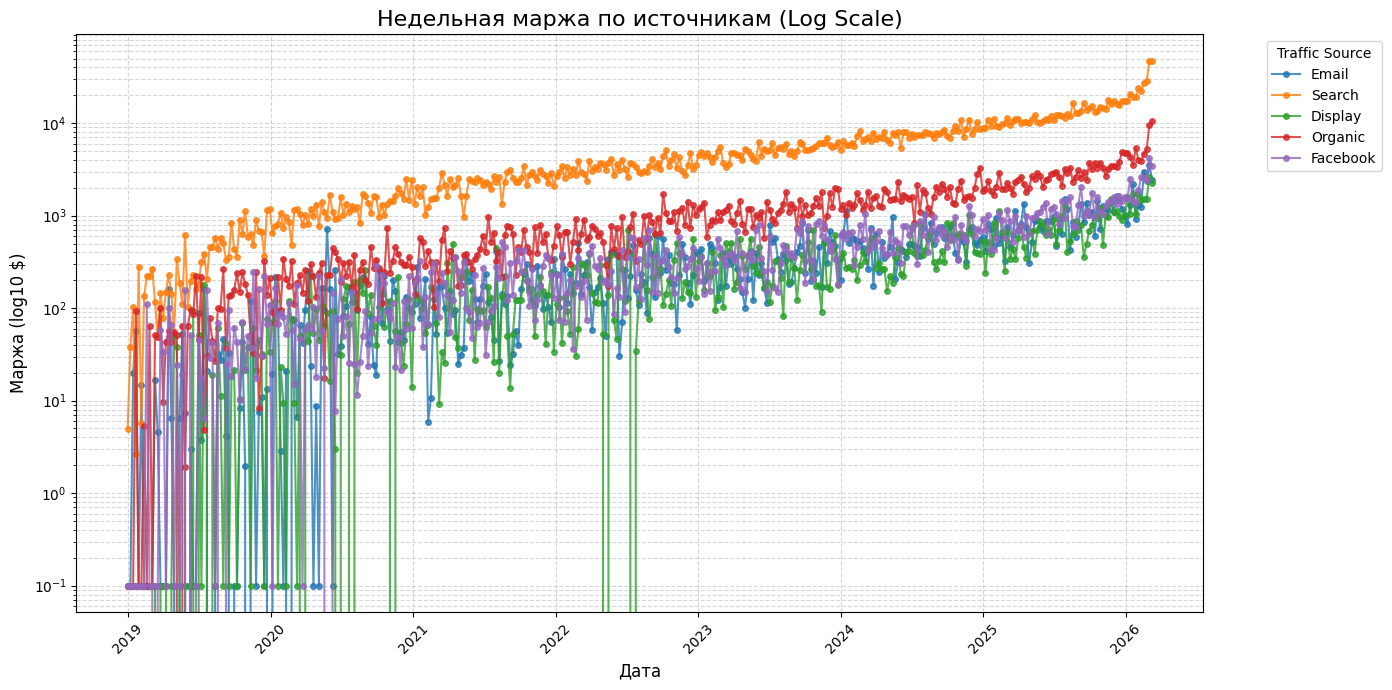

In [9]:
import matplotlib.pyplot as plt
import polars as pl

# 1. Агрегируем данные по неделям
weekly_data = (
    orders_processed
    .group_by_dynamic(
        "created_at",
        every="1w",
        group_by="traffic_source"
    )
    .agg(pl.col("margin").sum().alias("total_margin"))
    .collect()
)

# 2. Разворачиваем таблицу (Pivot)
pivot_margin = (
    weekly_data
    .pivot(values="total_margin", index="created_at", on="traffic_source")
    .sort("created_at")
    .fill_null(0.1) # Заменяем 0 на 0.1, так как log(0) не определен
)

# 3. Визуализация
plt.figure(figsize=(14, 7))

for column in pivot_margin.columns:
    if column != "created_at":
        plt.plot(
            pivot_margin["created_at"], 
            pivot_margin[column], 
            marker='o', 
            markersize=4,
            label=column,
            alpha=0.8
        )

# Переключаем ось Y в логарифмический режим
plt.yscale('log')

# Настройка сетки и подписей
plt.title("Недельная маржа по источникам (Log Scale)", fontsize=16)
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Маржа (log10 $)", fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5) # Сетка для обоих масштабов
plt.legend(title="Traffic Source", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [10]:
import polars as pl

# 1. Считаем браузеры, принудительно кастуя user_id в строку
user_browsers = (
    events_scan
    .with_columns(pl.col("user_id").cast(pl.Utf8)) # Кастуем в строку
    .group_by("user_id")
    .agg(pl.col("browser").mode().first())
    .collect()
)

# 2. Добавляем браузер в таблицу заказов, также кастуя user_id
orders_with_browser = (
    orders_processed
    .with_columns(pl.col("user_id").cast(pl.Utf8)) # Кастуем в строку
    .join(user_browsers.lazy(), on="user_id", how="left")
    .with_columns(pl.col("browser").fill_null("Unknown"))
)
# 3. Агрегируем по неделям
weekly_browser_margin = (
    orders_with_browser
    .sort("created_at") # КРИТИЧЕСКИ ВАЖНО: возвращаем хронологический порядок
    .group_by_dynamic(
        "created_at",
        every="1w",
        group_by=["traffic_source", "browser"]
    )
    .agg(pl.col("margin").sum().alias("total_margin"))
    .collect()
)

print(weekly_browser_margin.sort("total_margin", descending=True).head(10))

shape: (10, 4)
┌────────────────┬─────────┬─────────────────────────┬──────────────┐
│ traffic_source ┆ browser ┆ created_at              ┆ total_margin │
│ ---            ┆ ---     ┆ ---                     ┆ ---          │
│ str            ┆ str     ┆ datetime[μs, UTC]       ┆ f64          │
╞════════════════╪═════════╪═════════════════════════╪══════════════╡
│ Search         ┆ Chrome  ┆ 2026-03-02 00:00:00 UTC ┆ 27990.254461 │
│ Search         ┆ Chrome  ┆ 2026-03-09 00:00:00 UTC ┆ 27306.064754 │
│ Search         ┆ Chrome  ┆ 2026-02-23 00:00:00 UTC ┆ 15435.085968 │
│ Search         ┆ Chrome  ┆ 2026-02-16 00:00:00 UTC ┆ 15424.687839 │
│ Search         ┆ Chrome  ┆ 2026-02-09 00:00:00 UTC ┆ 14248.271633 │
│ Search         ┆ Chrome  ┆ 2026-02-02 00:00:00 UTC ┆ 13997.264267 │
│ Search         ┆ Chrome  ┆ 2026-01-12 00:00:00 UTC ┆ 12667.251824 │
│ Search         ┆ Chrome  ┆ 2026-01-19 00:00:00 UTC ┆ 11908.009088 │
│ Search         ┆ Chrome  ┆ 2026-01-05 00:00:00 UTC ┆ 11453.896741 │
│ Sea

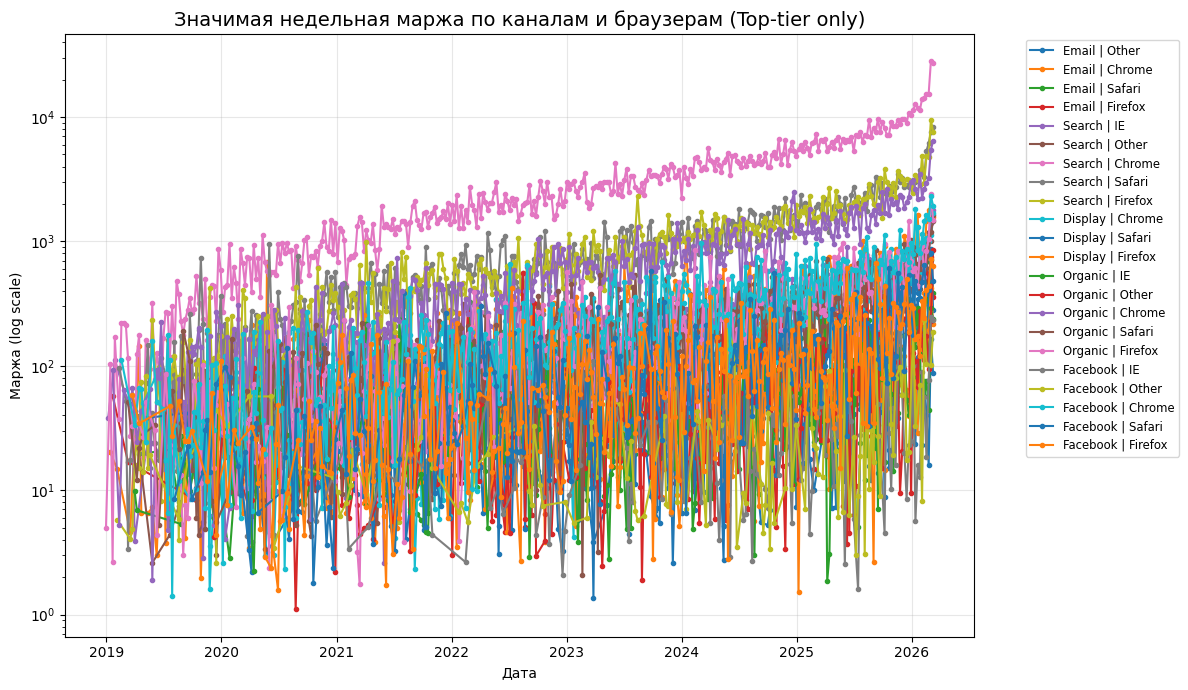

In [11]:
import matplotlib.pyplot as plt

# 1. Считаем общую маржу по каждой паре, чтобы найти лидеров
top_combinations = (
    weekly_browser_margin
    .group_by(["traffic_source", "browser"])
    .agg(pl.col("total_margin").sum().alias("grand_total"))
    .filter(pl.col("grand_total") > 5000) # Порог отсечения (можно менять)
    .select(["traffic_source", "browser"])
)

# 2. Фильтруем основные данные, оставляя только значимые пары
filtered_margin = weekly_browser_margin.join(
    top_combinations, 
    on=["traffic_source", "browser"], 
    how="inner"
)

# 3. Подготовка к графику
plot_df = (
    filtered_margin
    .with_columns((pl.col("traffic_source") + " | " + pl.col("browser")).alias("label"))
    .pivot(values="total_margin", index="created_at", on="label")
    .sort("created_at")
    # Теперь НЕ используем fill_null(0.1), чтобы пустые точки просто не соединялись
)

plt.figure(figsize=(12, 7))

for column in plot_df.columns:
    if column != "created_at":
        # Убираем значения <= 0, чтобы логарифм не выдал ошибку
        mask = plot_df[column] > 0
        if mask.any():
            plt.plot(
                plot_df["created_at"].filter(mask), 
                plot_df[column].filter(mask), 
                label=column, 
                marker='.', 
                linewidth=1.5
            )

plt.yscale('log')
plt.title("Значимая недельная маржа по каналам и браузерам (Top-tier only)", fontsize=14)
plt.ylabel("Маржа (log scale)")
plt.xlabel("Дата")
plt.grid(True, which="major", ls="-", alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

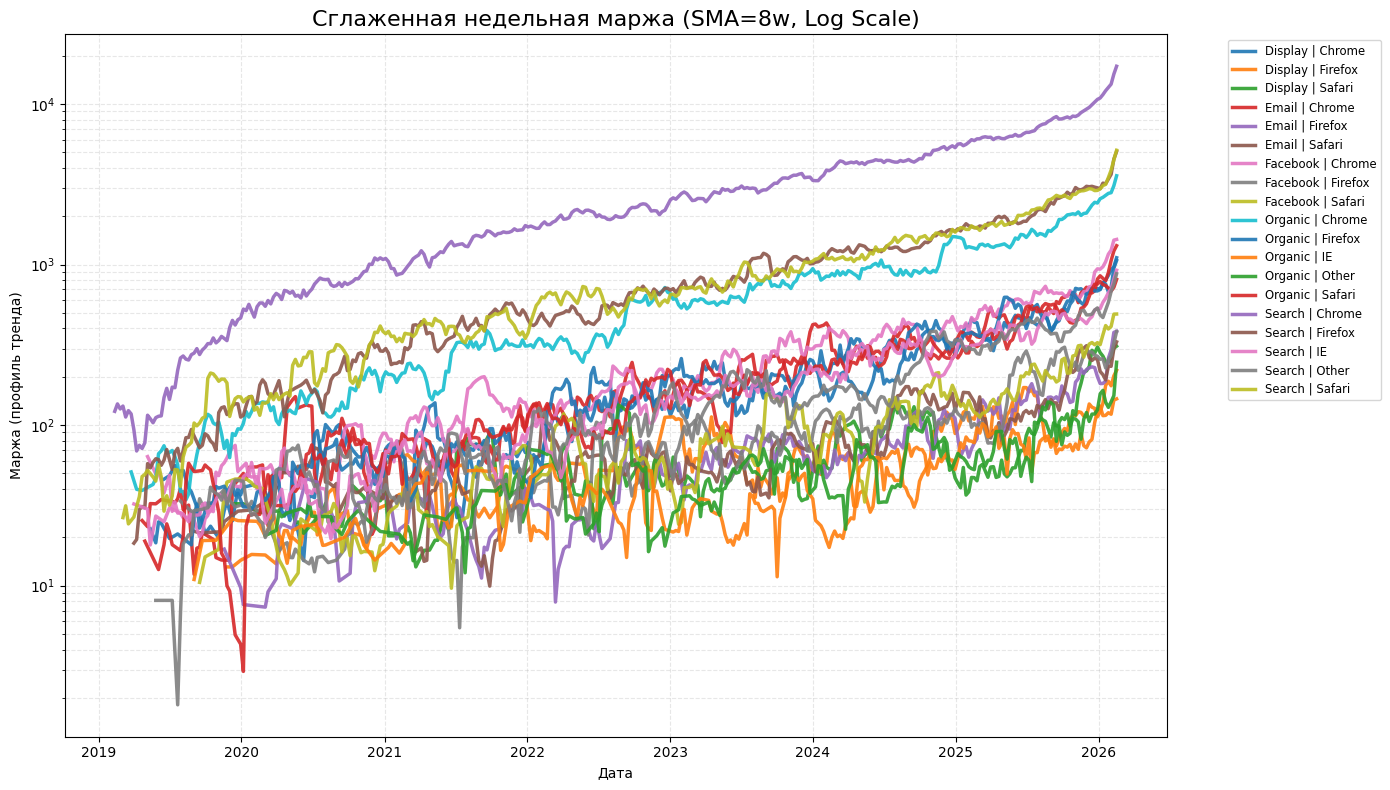

In [12]:
import matplotlib.pyplot as plt
import polars as pl

# 1. Параметры сглаживания
WINDOW_SIZE = 8 # Окно в 4 недели (примерно месяц)

# 2. Применяем скользящее среднее внутри каждой группы (Источник + Браузер)
smoothed_data = (
    weekly_browser_margin
    .sort(["traffic_source", "browser", "created_at"])
    .with_columns(
        pl.col("total_margin")
        .rolling_mean(window_size=WINDOW_SIZE, center=True)
        .over(["traffic_source", "browser"])
        .alias("smoothed_margin")
    )
    .filter(pl.col("smoothed_margin").is_not_null()) # Убираем края, где не хватило данных для окна
)

# 3. Фильтр по объему (оставляем только значимых)
top_labels = (
    smoothed_data
    .group_by(["traffic_source", "browser"])
    .agg(pl.col("total_margin").sum().alias("grand_total"))
    .filter(pl.col("grand_total") > 10000) # Порог для "высшей лиги"
    .select(["traffic_source", "browser"])
)

final_plot_df = (
    smoothed_data
    .join(top_labels, on=["traffic_source", "browser"], how="inner")
    .with_columns((pl.col("traffic_source") + " | " + pl.col("browser")).alias("label"))
    .pivot(values="smoothed_margin", index="created_at", on="label")
    .sort("created_at")
)

# 4. Визуализация
plt.figure(figsize=(14, 8))

for column in final_plot_df.columns:
    if column != "created_at":
        # Убираем нулевые значения для логарифмической шкалы
        mask = final_plot_df[column] > 1e-1 
        if mask.any():
            plt.plot(
                final_plot_df["created_at"].filter(mask), 
                final_plot_df[column].filter(mask), 
                label=column, 
                linewidth=2.5, # Делаем линии толще и мягче
                alpha=0.9
            )

plt.yscale('log')
plt.title(f"Сглаженная недельная маржа (SMA={WINDOW_SIZE}w, Log Scale)", fontsize=16)
plt.ylabel("Маржа (профиль тренда)")
plt.xlabel("Дата")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

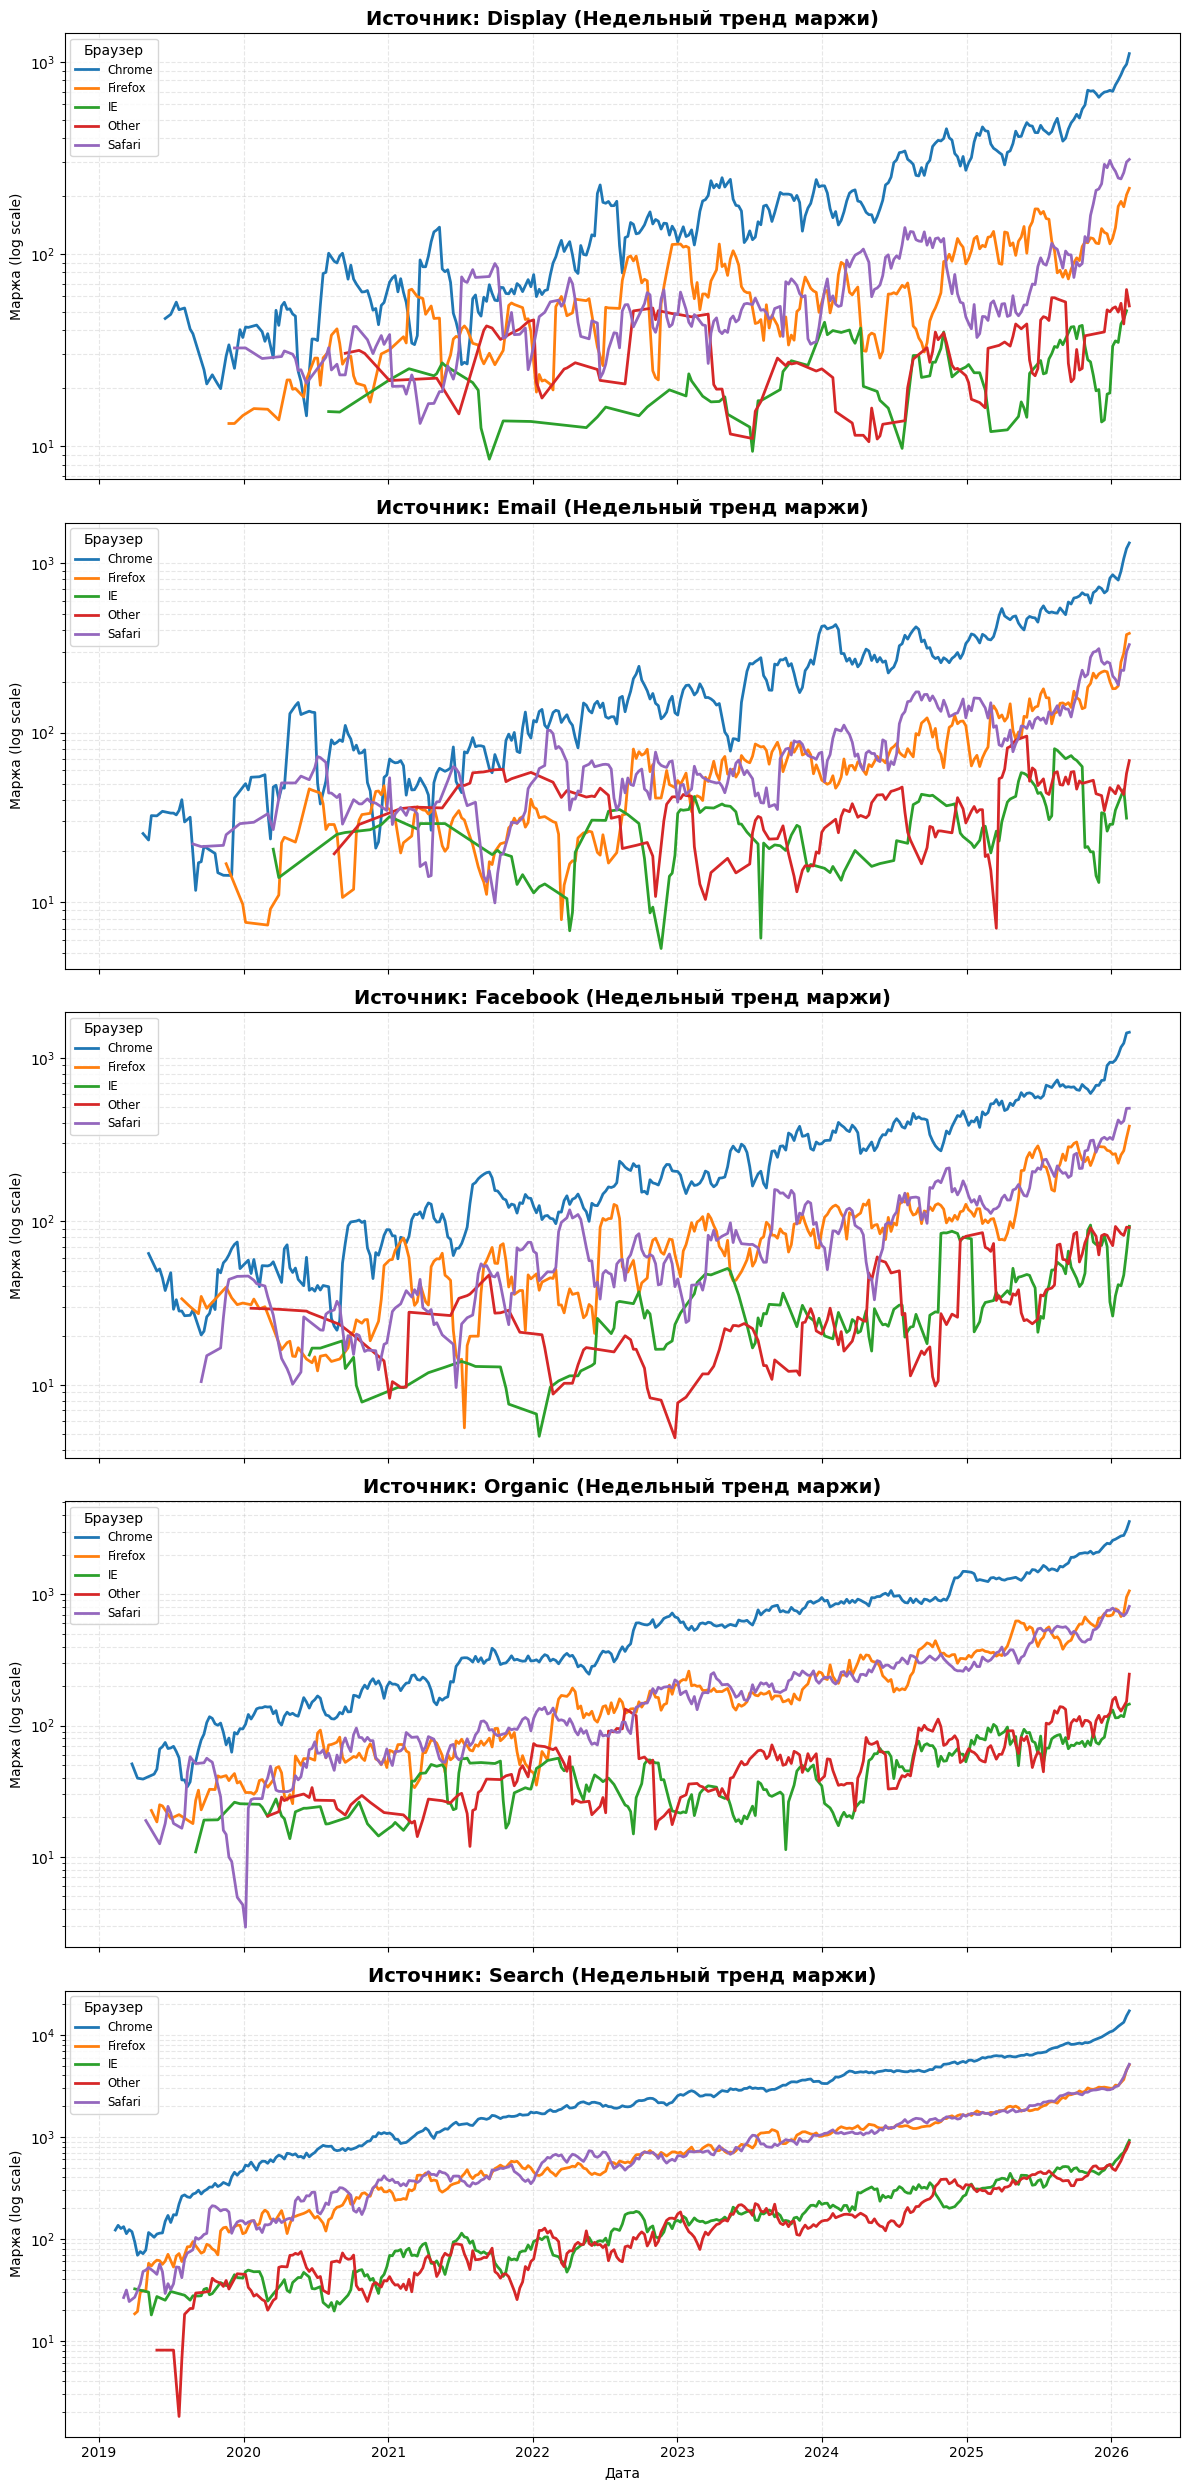

In [13]:
import matplotlib.pyplot as plt
import polars as pl

# 1. Берем наши сглаженные данные (из предыдущего шага)
# Убедитесь, что weekly_browser_margin и smoothed_data рассчитаны
sources = smoothed_data.select("traffic_source").unique().to_series().to_list()
num_sources = len(sources)

# 2. Создаем сетку графиков (один столбец, много строк)
fig, axes = plt.subplots(num_sources, 1, figsize=(12, 5 * num_sources), sharex=True)

# Если источник всего один, axes не будет списком, превращаем в список для цикла
if num_sources == 1:
    axes = [axes]

for i, source in enumerate(sources):
    ax = axes[i]
    
    # Фильтруем данные только для текущего источника
    source_data = (
        smoothed_data
        .filter(pl.col("traffic_source") == source)
        .pivot(values="smoothed_margin", index="created_at", on="browser")
        .sort("created_at")
    )
    
    # Строим линии для каждого браузера внутри этого источника
    for browser in source_data.columns:
        if browser != "created_at":
            mask = source_data[browser] > 0.1
            if mask.any():
                ax.plot(
                    source_data["created_at"].filter(mask), 
                    source_data[browser].filter(mask), 
                    label=browser, 
                    linewidth=2
                )
    
    # Настройки для конкретного подобъекта (источника)
    ax.set_yscale('log')
    ax.set_title(f"Источник: {source} (Недельный тренд маржи)", fontsize=14, fontweight='bold')
    ax.set_ylabel("Маржа (log scale)")
    ax.grid(True, which="both", ls="--", alpha=0.3)
    ax.legend(title="Браузер", loc='upper left', fontsize='small')

# Общие настройки
plt.xlabel("Дата")
plt.tight_layout()
plt.show()






# # 1. Подготовка "широкого" формата для сохранения
# export_pivot = (
#     smoothed_data
#     .with_columns(
#         (pl.col("traffic_source") + " | " + pl.col("browser")).alias("source_browser")
#     )
#     .pivot(
#         values="smoothed_margin", 
#         index="created_at", 
#         on="source_browser"
#     )
#     .sort("created_at")
# )

# # 2. Сохраняем
# output_pivot_path = base_dir / "margin_by_source_and_browser.csv"
# export_pivot.write_csv(output_pivot_path)

# print(f"Данные для детальных графиков сохранены: {output_pivot_path}")

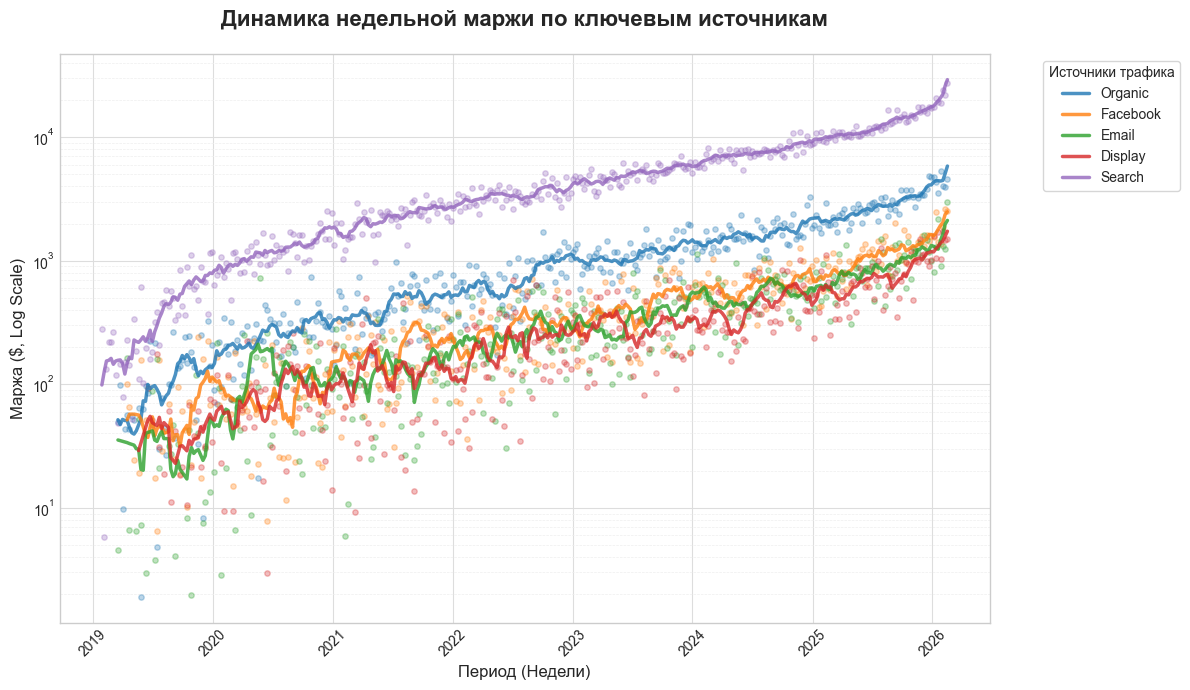

In [14]:
import matplotlib.pyplot as plt
import polars as pl

# 1. Подготовка данных со сглаживанием (SMA-3 для подавления шума)
# Оставляем только те источники, у которых суммарная маржа значима
top_sources = (
    weekly_data
    .group_by("traffic_source")
    .agg(pl.col("total_margin").sum())
    .filter(pl.col("total_margin") > 10000)
    .select("traffic_source")
)

plot_data = (
    weekly_data
    .join(top_sources, on="traffic_source", how="inner")
    .sort(["traffic_source", "created_at"])
    .with_columns(
        pl.col("total_margin")
        .rolling_mean(window_size=8, center=True)
        .over("traffic_source")
        .alias("smoothed_margin")
    )
)

# 2. Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid') # Опрятный светлый стиль
fig, ax = plt.subplots(figsize=(12, 7))

# Цветовая палитра (Colorblind-friendly)
colors = plt.cm.tab10.colors 

for i, source in enumerate(plot_data["traffic_source"].unique()):
    subset = plot_data.filter(pl.col("traffic_source") == source)
    
    # Рисуем только положительные значения (для корректного логарифма)
    valid_mask = subset["smoothed_margin"] > 0
    x = subset["created_at"].filter(valid_mask)
    y = subset["smoothed_margin"].filter(valid_mask)
    
    line, = ax.plot(x, y, label=source, linewidth=2.5, alpha=0.8, color=colors[i % 10])
    
    # Добавляем полупрозрачные точки реальных данных на фоне
    raw_y = subset["total_margin"].filter(valid_mask)
    ax.scatter(x, raw_y, color=line.get_color(), s=15, alpha=0.3)

# 3. Тонкая настройка осей и сетки
ax.set_yscale('log')
ax.set_title("Динамика недельной маржи по ключевым источникам", fontsize=16, pad=20, fontweight='bold')
ax.set_xlabel("Период (Недели)", fontsize=12)
ax.set_ylabel("Маржа ($, Log Scale)", fontsize=12)

# Сетка для основных и промежуточных порядков (важно для логарифмов)
ax.grid(True, which="major", color="#DDDDDD", linewidth=0.8)
ax.grid(True, which="minor", color="#EEEEEE", linestyle="--", linewidth=0.5)

# Легенда за пределами графика
ax.legend(title="Источники трафика", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




# # Определяем путь для сохранения (в ту же папку, где лежит скрипт)
# output_path = base_dir / "weekly_margin_analytics.csv"

# # Сохраняем результат
# # .collect() не нужен, так как plot_data у нас уже материализован (Eager)
# plot_data.write_csv(output_path)

# print(f"Файл успешно сохранен: {output_path}")
# print(f"Размер сохраненной таблицы: {plot_data.shape}")

In [15]:
# Смотрим все уникальные статусы
print(orders_processed.select("status").unique().collect())

shape: (5, 1)
┌────────────┐
│ status     │
│ ---        │
│ str        │
╞════════════╡
│ Processing │
│ Shipped    │
│ Cancelled  │
│ Returned   │
│ Complete   │
└────────────┘


Данные сохранены в total_margin_by_source.csv


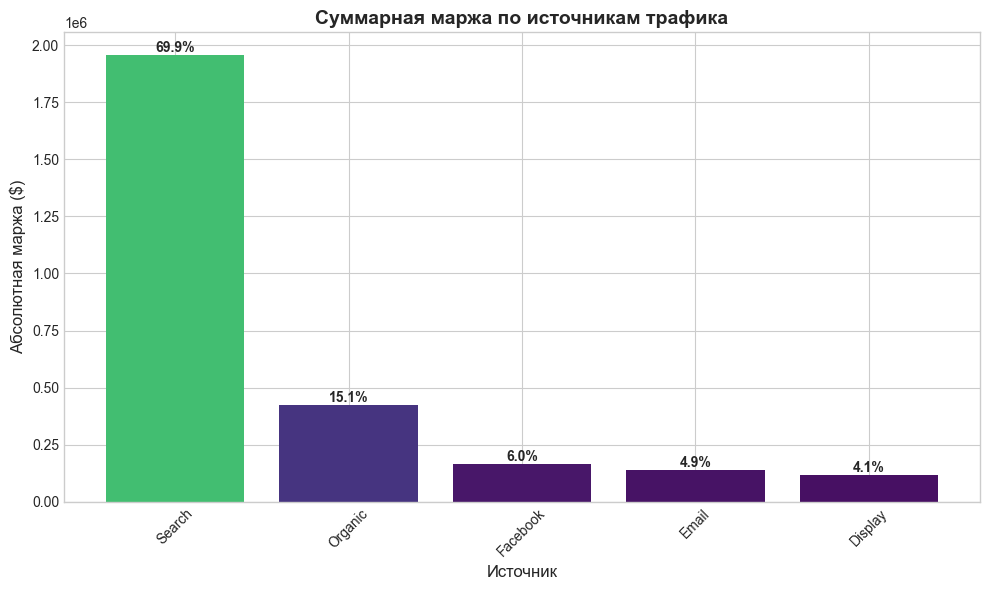

shape: (5, 3)
┌────────────────┬─────────────────┬────────────┐
│ traffic_source ┆ absolute_margin ┆ percentage │
│ ---            ┆ ---             ┆ ---        │
│ str            ┆ f64             ┆ f64        │
╞════════════════╪═════════════════╪════════════╡
│ Search         ┆ 1.9588e6        ┆ 69.911882  │
│ Organic        ┆ 423738.861856   ┆ 15.123745  │
│ Facebook       ┆ 166737.324485   ┆ 5.951054   │
│ Email          ┆ 137430.85048    ┆ 4.905071   │
│ Display        ┆ 115105.351467   ┆ 4.108247   │
└────────────────┴─────────────────┴────────────┘


In [16]:
import matplotlib.pyplot as plt
import polars as pl

# 1. Агрегация данных: расчет абсолютной маржи и доли в процентах
source_summary = (
    weekly_data
    .group_by("traffic_source")
    .agg(pl.col("total_margin").sum().alias("absolute_margin"))
    .with_columns(
        (pl.col("absolute_margin") / pl.col("absolute_margin").sum() * 100).alias("percentage")
    )
    .sort("absolute_margin", descending=True)
)

# 2. Сохранение в CSV
output_path = "total_margin_by_source.csv"
source_summary.write_csv(output_path)
print(f"Данные сохранены в {output_path}")

# 3. Визуализация
fig, ax = plt.subplots(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# Построение столбчатой диаграммы
bars = ax.bar(
    source_summary["traffic_source"], 
    source_summary["absolute_margin"], 
    color=plt.cm.viridis(source_summary["percentage"] / 100)
)

# Настройка осей и заголовков
ax.set_title("Суммарная маржа по источникам трафика", fontsize=14, fontweight='bold')
ax.set_ylabel("Абсолютная маржа ($)", fontsize=12)
ax.set_xlabel("Источник", fontsize=12)

# Добавление подписей с процентами над столбцами
for bar, pct in zip(bars, source_summary["percentage"]):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2., height,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Вывод результирующей таблицы в ячейку
print(source_summary)

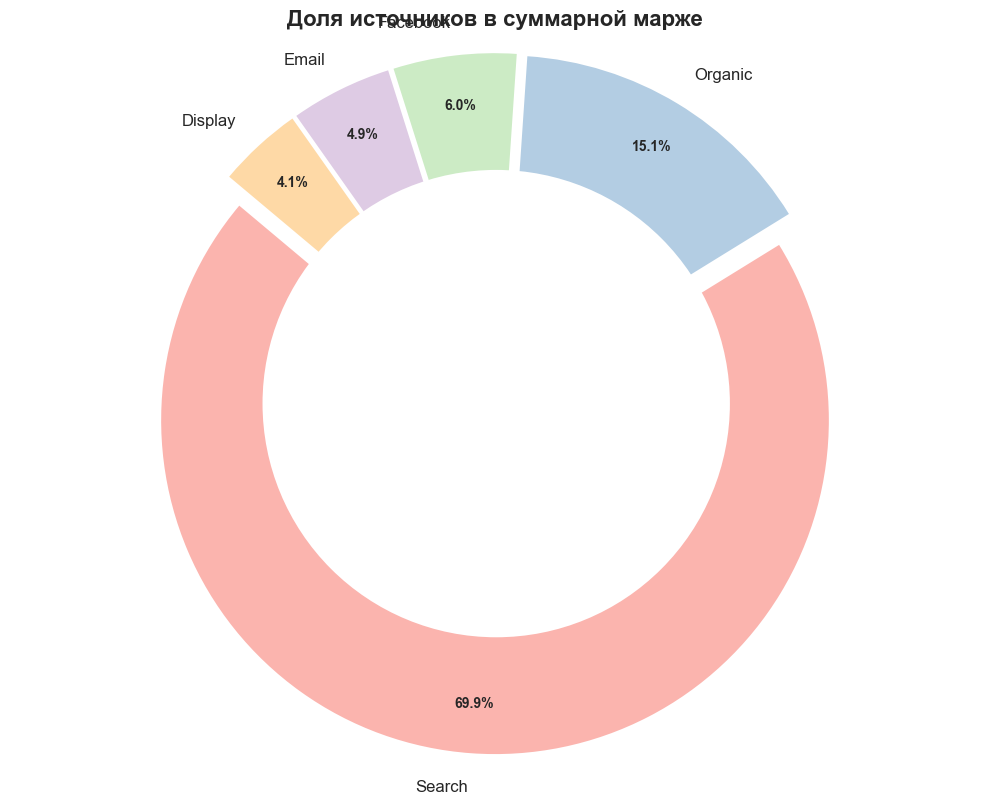

In [17]:
# 1. Подготовка данных (используем уже агрегированный source_summary)
labels = source_summary["traffic_source"].to_list()
sizes = source_summary["absolute_margin"].to_list()

# 2. Настройка визуализации
fig, ax = plt.subplots(figsize=(10, 8))

# Цветовая схема
colors = plt.cm.Pastel1.colors

# Построение диаграммы
wedges, texts, autotexts = ax.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    pctdistance=0.85, # Смещение процентов к краю
    explode=[0.05] * len(labels) # Небольшой "взрыв" всех секторов для наглядности
)

# Стилизация текста
plt.setp(autotexts, size=10, weight="bold")
plt.setp(texts, size=12)

# Рисуем круг в центре, чтобы превратить pie chart в donut chart (опционально, для стиля)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

ax.set_title("Доля источников в суммарной марже", fontsize=16, fontweight='bold')
ax.axis('equal')  # Чтобы круг был кругом

plt.tight_layout()
plt.show()



In [18]:
import polars as pl

# 1. Анализ маржи с неопределенным источником трафика
# В физической интерпретации: оценка вклада фоновых шумов, не привязанных к конкретным каналам
missing_source_stats = (
    orders_processed
    .filter(pl.col("traffic_source").is_null())
    .select(pl.col("margin").sum().alias("unclassified_margin"))
    .collect()
)

# 2. Анализ маржи без пространственной привязки
# Используем delivery_latitude/longitude, обнаруженные в схеме вашего датасета
missing_geo_stats = (
    orders_processed
    .filter(pl.col("delivery_latitude").is_null() | pl.col("delivery_longitude").is_null())
    .select(pl.col("margin").sum().alias("non_localized_margin"))
    .collect()
)

# 3. Суммарная маржа системы для нормировки
total_system_margin = orders_processed.select(pl.col("margin").sum()).collect()[0, 0]

# --- Вывод результатов (Reporting) ---
unclassified = missing_source_stats['unclassified_margin'][0]
non_localized = missing_geo_stats['non_localized_margin'][0]

print(f"--- Статистика неопределенности данных ---")
print(f"Маржа без источника:  ${unclassified:,.2f} ({(unclassified/total_system_margin)*100:.2f}% от общей)")
print(f"Маржа без координат:  ${non_localized:,.2f} ({(non_localized/total_system_margin)*100:.2f}% от общей)")
print(f"Общая маржа системы:  ${total_system_margin:,.2f}")

--- Статистика неопределенности данных ---
Маржа без источника:  $0.00 (0.00% от общей)
Маржа без координат:  $0.00 (0.00% от общей)
Общая маржа системы:  $2,801,811.65


In [19]:
import pandas as pd
import polars as pl
from pathlib import Path

data_path = "data.csv"

# --- 1. ПУТЬ PANDAS (Твой текущий подход) ---
df_pd = pd.read_csv(data_path)
df_pd = df_pd.drop_duplicates()  # Pandas удаляет только полные дубликаты строк

# Расчет p_success (на уровне строк/позиций)
n_comp_pd = len(df_pd[df_pd['status'] == 'Complete'])
n_fail_pd = len(df_pd[df_pd['status'].isin(['Returned', 'Cancelled'])])
p_success_pd = n_comp_pd / (n_comp_pd + n_fail_pd)

# Взвешенная маржа в Pandas
df_pd['weight'] = df_pd['status'].map(lambda x: 1.0 if x == 'Complete' else (0.0 if x in ['Returned', 'Cancelled'] else p_success_pd))
total_margin_pd = ((df_pd['sale_price'] - df_pd['cost']) * df_pd['weight']).sum()

# --- 2. ПУТЬ POLARS (Исправленный, чтобы найти разницу) ---
# Мы специально сделаем два варианта в Polars, чтобы ты увидел, где ошибка
orders_lazy = pl.scan_csv(data_path)

# Вариант А: Твой старый (ошибочный) — схлопывание по order_id
margin_pl_bug = (
    orders_lazy
    .unique(subset=["order_id"]) # ВОТ ОНА, ОШИБКА: удаляются товары внутри заказа
    .collect()
    .select(((pl.col("sale_price") - pl.col("cost")) * p_success_pd).sum()) # упрощенно для теста
)[0, 0]

# Вариант Б: Корректный — дедупликация по позициям (order_item_id)
margin_pl_correct = (
    orders_lazy
    .unique(subset=["order_item_id"]) # Сохраняем все товары
    .with_columns([
        pl.when(pl.col("status") == "Complete").then(1.0)
          .when(pl.col("status").is_in(["Returned", "Cancelled"])).then(0.0)
          .otherwise(p_success_pd)
          .alias("weight")
    ])
    .select(((pl.col("sale_price") - pl.col("cost")) * pl.col("weight")).sum())
    .collect()
)[0, 0]

# --- ИТОГОВОЕ СРАВНЕНИЕ ---
print(f"{'Method':<35} | {'Total Margin':<20}")
print("-" * 60)
print(f"{'Pandas (Items-based)':<35} | ${total_margin_pd:>18,.2f}")
print(f"{'Polars (BUG: order_id subset)':<35} | ${margin_pl_bug:>18,.2f}")
print(f"{'Polars (CORRECT: item_id subset)':<35} | ${margin_pl_correct:>18,.2f}")
print("-" * 60)
print(f"РАЗНИЦА (Pandas - Bug Polars): ${total_margin_pd - margin_pl_bug:>18,.2f}")

Method                              | Total Margin        
------------------------------------------------------------
Pandas (Items-based)                | $      2,801,811.65
Polars (BUG: order_id subset)       | $      1,617,038.83
Polars (CORRECT: item_id subset)    | $      2,801,811.65
------------------------------------------------------------
РАЗНИЦА (Pandas - Bug Polars): $      1,184,772.82
